In [1]:
from qcodes.parameters import MultiParameter
import numpy as np
from qcodes import Parameter
import sys
from time import sleep
import pyvisa
import qcodes as qc
import time
import matplotlib.pyplot as plt

In [2]:
from qcodes.dataset import Measurement
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
initialise_or_create_database_at("./2026-02-12_SNSPD2_dark_counts.db")

from time import sleep, monotonic

# Set up experiment
exp_name = 'Dark_counts_12_02_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Experiment loaded. Last ID no: 28


Square Meander RF line 7

In [4]:
data = load_by_id(11).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
total_time = data['total_time']['total_time']
bin_time = data['bin_time']['bin_time']
DCR1 = data['DCR1']['DCR1']
DCR2 = data['DCR2']['DCR2']

In [6]:
n_captures = total_time
meas_time = trace_time[0]*n_captures

# Corrected dark counts calculations
DCR1_corrected = total_counts1/meas_time
DCR2_corrected = total_counts2/meas_time

In [10]:
len(meas_time)

48

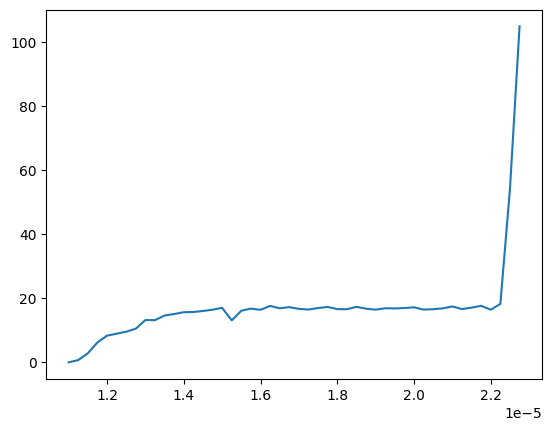

In [8]:
plt.plot(current, DCR1_corrected)

In [15]:
import pandas as pd

# Sample DataFrame
DCR_ID11 = {'current': current, 
            'total_counts1': total_counts1, 
            "total_counts2": total_counts2,
            'DCR1': DCR1_corrected, 
            'DCR2': DCR2_corrected,
            'n_captures': n_captures,
            'meas_time': meas_time, 
            'trace_time': trace_time, 
            'bin_time': bin_time,
            'threshold1': threshold1,
            'threshold2': threshold2}

df = pd.DataFrame(DCR_ID11)

# Export to a CSV file named 'output_file.csv'
df.to_csv('DCR_ID11_full.csv')


In [18]:
# Sample DataFrame
DCR_ID11_counts = {'counts1': counts1, 
            "counts2": counts2}

df = pd.DataFrame(DCR_ID11_counts)

# Export to a CSV file named 'output_file.csv'
df.to_csv('DCR_ID11_counts.csv')

In [ ]:
yoko.current, yoko.current()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("total_time", total_time), 
                             ("bin_time", bin_time), 
                             ("DCR1", DCR1), 
                             ("DCR2", DCR2))